# S1 Backtest — volatility targeting + IC conviction bake-off (IS)

Set **`N_STAR`**, **`TIMING_STAR`**, **`WEIGHT_STAR`**, **`INV_VOL_WINDOW_STAR`**, and **`STOP_STAR`** from notebooks 01–06.
On **research IS only**, test exposure overlays that scale gross without retuning Ridge / N / timing / weights.

### Overlays
- **Vol targeting:** keep the same names/weights each Monday; scale gross so trailing strategy vol sits near a target (e.g. 10–12% ann.).
- **IC conviction:** multiply that leverage by `clip(k * Bayesian IC, floor, cap)`.
- **Deadband:** optional — ignore tiny week-to-week leverage changes (see step 6).

Pick **`VT_STAR`** / **`IC_STAR`** by IS max-DD and 2022 improvement subject to Sharpe not degrading. Copy into `08_oos_tearsheet`. No CSV writes.


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.costs import DEFAULT_COSTS, cost_summary
from backtest.s1_equities.portfolio import WEIGHT_INV_VOL
from backtest.s1_equities.report import (
    calendar_year_table,
    drawdown_episodes,
    plot_equity_overlay,
    plot_leverage_and_vol,
)
from backtest.s1_equities.runner import run_backtest, summarize_periods
from backtest.s1_equities.signals import (
    TIMING_MON_OPEN_MON_OPEN,
    default_backtest_paths,
    is_mask_from_preds,
    load_ohlc_panels,
    load_predictions,
    prediction_path_for_timing,
    score_matrix,
)
from backtest.s1_equities.stops import parse_stop_star
from models.s1_equities.training_common import LABEL_COL, date_ic_series
from risk.analytics.s1_equities.signal_conviction import (
    ICScaleConfig,
    bayes_ic_series,
    ic_scale_star,
    parse_ic_scale_star,
)
from risk.analytics.s1_equities.vol_targeting import (
    ESTIMATOR_BAYES,
    ESTIMATOR_EWM,
    ESTIMATOR_ROLLING,
    VolTargetConfig,
    leverage_series,
    parse_vol_target_star,
    vol_target_star,
)

PATHS = default_backtest_paths(ROOT)

N_STAR = 15
TIMING_STAR = TIMING_MON_OPEN_MON_OPEN
WEIGHT_STAR = WEIGHT_INV_VOL
INV_VOL_WINDOW_STAR = 42
STOP_STAR = "pct_20"
STOP_CFG = parse_stop_star(STOP_STAR)
PRED_PATH = prediction_path_for_timing(PATHS, TIMING_STAR)

print(f"N_STAR={N_STAR}  TIMING_STAR={TIMING_STAR}  WEIGHT_STAR={WEIGHT_STAR}")
print(f"INV_VOL_WINDOW_STAR={INV_VOL_WINDOW_STAR}  STOP_STAR={STOP_STAR}")
print(f"predictions={PRED_PATH}")
display(pd.Series(cost_summary(DEFAULT_COSTS), name="bps").to_frame())


N_STAR=15  TIMING_STAR=mon_open_mon_open  WEIGHT_STAR=inv_vol
INV_VOL_WINDOW_STAR=42  STOP_STAR=pct_20
predictions=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_linear_slim_ffill_is_predictions.parquet


,bps
commission_bps,0.0
regulatory_bps,0.5
half_spread_bps,5.0
open_slippage_bps,10.0
close_slippage_bps,5.0
short_borrow_bps,0.0
open_one_way_bps,15.5
close_one_way_bps,10.5


## 1. Load IS panel + baseline anatomy (2022)


In [2]:
preds = load_predictions(PRED_PATH)
scores = score_matrix(preds)
is_mask = is_mask_from_preds(preds)
opens, highs, lows, closes = load_ohlc_panels(PATHS["features"], tickers=list(scores.columns))

ics = date_ic_series(preds, "score", label_col=LABEL_COL)
n_names = preds.groupby("date")["ticker"].nunique()
n_names.index = pd.to_datetime(n_names.index)
ic_inputs = pd.DataFrame({"ic": ics, "n_names": n_names}).sort_index()

baseline = run_backtest(
    scores, opens, closes,
    n=N_STAR, timing_mode=TIMING_STAR, weight_mode=WEIGHT_STAR,
    inv_vol_window=INV_VOL_WINDOW_STAR, costs=DEFAULT_COSTS,
    date_mask=is_mask, highs=highs, lows=lows, stop=STOP_CFG,
)
base_sm = summarize_periods(baseline.period_returns)
print("Baseline IS:", {k: base_sm[k] for k in ["sharpe", "vol", "max_drawdown", "total_return"]})
display(calendar_year_table(baseline.period_returns))
display(drawdown_episodes(baseline.equity, top_n=5))


Baseline IS: {'sharpe': 0.8819199703233338, 'vol': 0.07821967966569983, 'max_drawdown': -0.20756043778106015, 'total_return': 0.6810820659838535}


,n_periods,total_return,vol,sharpe,max_drawdown
year,,,,,
2015,41,0.031822,0.051398,0.798290,-0.029064
2016,52,0.051292,0.061449,0.844578,-0.037468
2017,52,0.106991,0.058018,1.782079,-0.023735
2018,53,0.113864,0.056260,1.910093,-0.032227
2019,52,0.137943,0.061851,2.122241,-0.036360
2020,52,0.208382,0.090899,2.130710,-0.046585
2021,52,0.073990,0.080263,0.929452,-0.035254
2022,52,-0.168839,0.126981,-1.391196,-0.150135
2023,4,0.023940,0.064896,4.777537,-0.000366


,depth,peak_date,trough_date,recovery_date,length_weeks,recovery_weeks
0,-0.207560,2021-11-15,2022-10-31,NaT,50.000000,NaN
1,-0.046585,2020-01-06,2020-04-06,2020-05-18,13.000000,19.000000
2,-0.037468,2016-01-19,2016-04-25,2016-08-08,13.857143,28.857143
3,-0.036360,2019-04-22,2019-05-20,2019-07-08,4.000000,11.000000
4,-0.035796,2015-03-22,2015-06-22,2015-08-24,13.142857,22.142857


## 2. Estimator diagnostics (no overlay in the backtest yet)

Compare trailing vol estimates on the **baseline unlevered** weekly net returns.


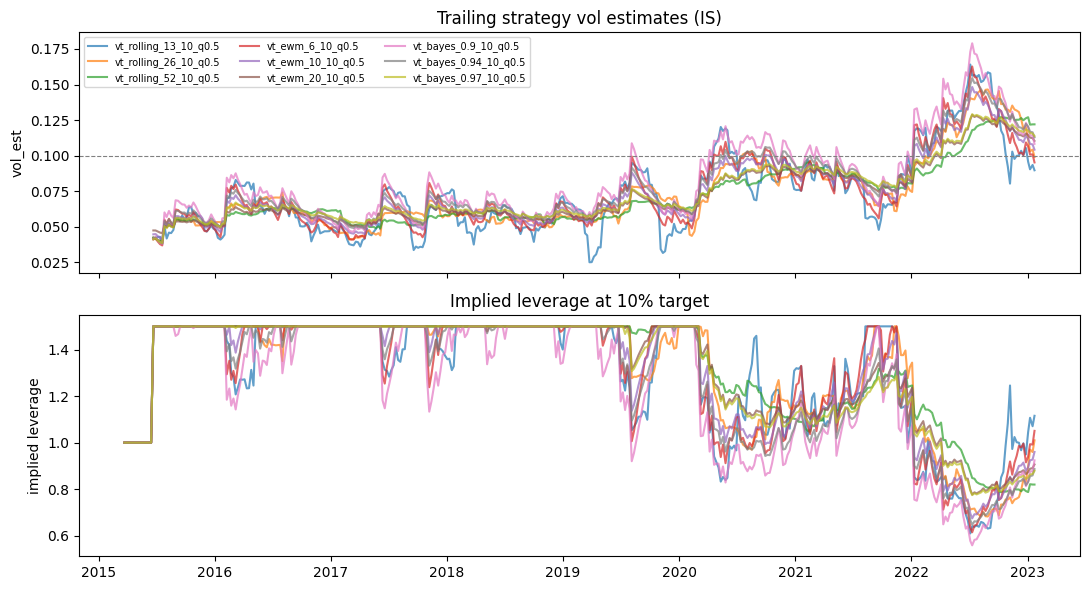

In [3]:
base_r = baseline.period_returns_base if len(baseline.period_returns_base) else baseline.period_returns

diag_cfgs = []
for w in (13, 26, 52):
    diag_cfgs.append(VolTargetConfig(estimator=ESTIMATOR_ROLLING, window=w, min_periods=min(13, w), target_ann_vol=0.10, deadband=0.0))
for hl in (6.0, 10.0, 20.0):
    diag_cfgs.append(VolTargetConfig(estimator=ESTIMATOR_EWM, halflife=hl, min_periods=13, target_ann_vol=0.10, deadband=0.0))
for d in (0.90, 0.94, 0.97):
    diag_cfgs.append(VolTargetConfig(estimator=ESTIMATOR_BAYES, forget=d, min_periods=13, target_ann_vol=0.10, quantile=0.5, deadband=0.0))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for cfg in diag_cfgs:
    fr = leverage_series(base_r, cfg)
    label = cfg.label()
    axes[0].plot(fr.index, fr["vol_est"], label=label, alpha=0.7)
    axes[1].plot(fr.index, fr["leverage"], label=label, alpha=0.7)
axes[0].axhline(0.10, color="gray", ls="--", lw=0.8)
axes[0].set_ylabel("vol_est")
axes[0].set_title("Trailing strategy vol estimates (IS)")
axes[1].set_ylabel("implied leverage")
axes[1].set_title("Implied leverage at 10% target")
axes[0].legend(fontsize=7, ncol=3, loc="best")
plt.tight_layout()
plt.show()


## 3. Main vol-target grid (Bayes primary)

Grid Bayes × target × forget × quantile, plus best rolling/EWM comparators and a **matched constant-haircut control** for q=0.75.


In [4]:
def run_vt(cfg, ic_cfg=None):
    return run_backtest(
        scores, opens, closes,
        n=N_STAR, timing_mode=TIMING_STAR, weight_mode=WEIGHT_STAR,
        inv_vol_window=INV_VOL_WINDOW_STAR, costs=DEFAULT_COSTS,
        date_mask=is_mask, highs=highs, lows=lows, stop=STOP_CFG,
        vol_target=cfg,
        ic_scale=ic_cfg if ic_cfg is not None else ICScaleConfig(enabled=False),
        ic_inputs=ic_inputs if (ic_cfg is not None and ic_cfg.enabled) else None,
    )

def row_from_result(label, res, year=2022):
    sm = summarize_periods(res.period_returns)
    yt = calendar_year_table(res.period_returns)
    yret = float(yt.loc[year, "total_return"]) if year in yt.index else np.nan
    eps = drawdown_episodes(res.equity, top_n=1)
    dd_len = float(eps.iloc[0]["length_weeks"]) if len(eps) else np.nan
    lev = res.leverage.dropna()
    return {
        "label": label,
        "sharpe": sm["sharpe"],
        "max_drawdown": sm["max_drawdown"],
        "dd_length_weeks": dd_len,
        "vol": sm["vol"],
        "total_return": sm["total_return"],
        "ret_2022": yret,
        "mean_leverage": float(lev.mean()) if len(lev) else np.nan,
        "mean_turnover": float(res.turnover.mean()) if len(res.turnover) else np.nan,
        "mean_cost_drag": float((res.period_returns_gross - res.period_returns).mean()),
    }

vt_results = {"baseline": baseline}
rows = [row_from_result("baseline", baseline)]

grid = []
for tgt in (0.10, 0.12):
    for forget in (0.90, 0.94, 0.97):
        for q in (0.5, 0.75):
            grid.append(VolTargetConfig(
                estimator=ESTIMATOR_BAYES, forget=forget, target_ann_vol=tgt,
                quantile=q, min_periods=13, deadband=0.0,
            ))
# rolling / ewm comparators
grid.append(VolTargetConfig(estimator=ESTIMATOR_ROLLING, window=26, min_periods=13, target_ann_vol=0.10, deadband=0.0))
grid.append(VolTargetConfig(estimator=ESTIMATOR_EWM, halflife=10.0, min_periods=13, target_ann_vol=0.10, deadband=0.0))

for cfg in grid:
    lab = cfg.label()
    res = run_vt(cfg)
    vt_results[lab] = res
    rows.append(row_from_result(lab, res))
    print(f"{lab}: sharpe={rows[-1]['sharpe']:.3f} dd={rows[-1]['max_drawdown']:.3%} ret22={rows[-1]['ret_2022']:.3%}")

# Constant-haircut control: match mean leverage of best q=0.75 Bayes at 10%
q75 = [r for r in rows if "q0.75" in r["label"] and "bayes" in r["label"] and "_10_" in r["label"]]
if q75:
    best_q75 = max(q75, key=lambda r: r["sharpe"])
    mean_l = best_q75["mean_leverage"]
    haircut = VolTargetConfig(
        enabled=True, estimator=ESTIMATOR_BAYES, forget=0.94, target_ann_vol=0.10,
        quantile=0.5, min_periods=13, deadband=0.0,
        # emulate constant haircut via clipping max_leverage to mean_l of q75 run
        max_leverage=float(mean_l), min_leverage=float(mean_l),
        warmup_leverage=float(mean_l),
    )
    # True constant: disable estimator path by enabled with min=max leverage — use a custom run:
    # simpler: scale baseline returns is wrong for costs; instead set target very high and clamp
    const_cfg = VolTargetConfig(
        estimator=ESTIMATOR_BAYES, forget=0.94, target_ann_vol=0.10, quantile=0.5,
        min_periods=13, deadband=0.0, min_leverage=float(mean_l), max_leverage=float(mean_l),
        warmup_leverage=float(mean_l),
    )
    cres = run_vt(const_cfg)
    vt_results["const_haircut_q75_match"] = cres
    rows.append(row_from_result("const_haircut_q75_match", cres))
    print(f"const_haircut_q75_match (L={mean_l:.3f}): sharpe={rows[-1]['sharpe']:.3f}")

vt_df = pd.DataFrame(rows).set_index("label")
display(vt_df.sort_values(["max_drawdown", "ret_2022"], ascending=[False, False]))


vt_bayes_0.9_10_q0.5: sharpe=1.095 dd=-19.114% ret22=-14.976%
vt_bayes_0.9_10_q0.75: sharpe=1.121 dd=-17.659% ret22=-13.801%
vt_bayes_0.94_10_q0.5: sharpe=1.071 dd=-20.291% ret22=-16.082%
vt_bayes_0.94_10_q0.75: sharpe=1.098 dd=-18.854% ret22=-14.908%
vt_bayes_0.97_10_q0.5: sharpe=1.053 dd=-21.466% ret22=-17.275%
vt_bayes_0.97_10_q0.75: sharpe=1.077 dd=-20.232% ret22=-16.249%
vt_bayes_0.9_12_q0.5: sharpe=1.036 dd=-22.395% ret22=-17.789%
vt_bayes_0.9_12_q0.75: sharpe=1.062 dd=-20.854% ret22=-16.408%
vt_bayes_0.94_12_q0.5: sharpe=1.018 dd=-23.795% ret22=-19.089%
vt_bayes_0.94_12_q0.75: sharpe=1.036 dd=-22.265% ret22=-17.711%
vt_bayes_0.97_12_q0.5: sharpe=1.005 dd=-25.257% ret22=-20.494%
vt_bayes_0.97_12_q0.75: sharpe=1.021 dd=-23.876% ret22=-19.292%
vt_rolling_26_10_q0.5: sharpe=1.028 dd=-21.765% ret22=-17.180%
vt_ewm_10_10_q0.5: sharpe=1.047 dd=-21.423% ret22=-16.972%
const_haircut_q75_match (L=1.173): sharpe=0.882


,sharpe,max_drawdown,dd_length_weeks,vol,total_return,ret_2022,mean_leverage,mean_turnover,mean_cost_drag
label,,,,,,,,,
vt_bayes_0.9_10_q0.75,1.121039,-0.176589,50.0,0.083590,1.035427,-0.138012,1.173481,0.209119,0.000323
vt_bayes_0.94_10_q0.75,1.098448,-0.188544,50.0,0.087544,1.069596,-0.149081,1.224332,0.213985,0.000330
vt_bayes_0.9_10_q0.5,1.095427,-0.191144,50.0,0.088356,1.078632,-0.149765,1.235934,0.218983,0.000338
vt_bayes_0.97_10_q0.75,1.076769,-0.202322,50.0,0.092747,1.122947,-0.162494,1.285803,0.222300,0.000343
vt_bayes_0.94_10_q0.5,1.071157,-0.202906,50.0,0.092042,1.102808,-0.160825,1.279630,0.222842,0.000344
baseline,0.881920,-0.207560,50.0,0.078220,0.681082,-0.168839,1.000000,0.172833,0.000266
vt_bayes_0.9_12_q0.75,1.061926,-0.208538,50.0,0.093296,1.108875,-0.164076,1.294017,0.227523,0.000351
vt_ewm_10_10_q0.5,1.047394,-0.214231,50.0,0.094974,1.112896,-0.169725,1.311303,0.228507,0.000352
vt_bayes_0.97_10_q0.5,1.053234,-0.214662,50.0,0.096077,1.139863,-0.172754,1.319922,0.228222,0.000352


## 4. IC conviction overlay


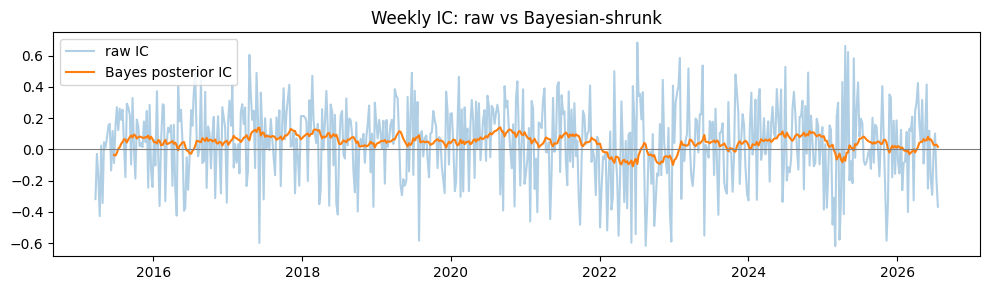

Provisional VT_STAR=vt_bayes_0.9_10_q0.75
vt_bayes_0.9_10_q0.75__ic_k15_0.94_f0.25_c1.25: sharpe=1.000 dd=-10.486%
vt_bayes_0.9_10_q0.75__ic_k25_0.94_f0.25_c1.25: sharpe=0.981 dd=-13.047%
vt_bayes_0.9_10_q0.75__ic_k40_0.94_f0.25_c1.25: sharpe=1.059 dd=-15.341%


,sharpe,max_drawdown,dd_length_weeks,vol,total_return,ret_2022,mean_leverage,mean_turnover,mean_cost_drag
label,,,,,,,,,
vt_bayes_0.9_10_q0.75__ic_k15_0.94_f0.25_c1.25,1.000084,-0.104863,59.0,0.070288,0.706496,-0.060932,0.958041,0.198478,0.000306
vt_bayes_0.9_10_q0.75__ic_k25_0.94_f0.25_c1.25,0.980779,-0.130469,50.0,0.081676,0.831009,-0.087451,1.124637,0.223909,0.000345
vt_bayes_0.9_10_q0.75__ic_k40_0.94_f0.25_c1.25,1.059394,-0.153411,50.0,0.086781,1.002887,-0.112694,1.187791,0.223396,0.000344


In [5]:
# Show shrinkage: raw IC vs Bayes posterior
ic_cfg_demo = ICScaleConfig(k=25.0, forget=0.94, min_mult=0.25, max_mult=1.25, min_periods=13)
ic_demo = bayes_ic_series(ic_inputs["ic"], ic_inputs["n_names"], ic_cfg_demo)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ic_inputs.index, ic_inputs["ic"], alpha=0.35, label="raw IC")
ax.plot(ic_demo.index, ic_demo["ic_posterior"], label="Bayes posterior IC")
ax.axhline(0.0, color="gray", lw=0.8)
ax.legend()
ax.set_title("Weekly IC: raw vs Bayesian-shrunk")
plt.tight_layout()
plt.show()

# Provisional VT from grid: prefer Bayes, better DD than baseline, Sharpe not worse
cand = vt_df.drop(index=["baseline"], errors="ignore")
cand = cand[cand.index.str.contains("bayes")]
base_sh = float(vt_df.loc["baseline", "sharpe"])
base_dd = float(vt_df.loc["baseline", "max_drawdown"])
ok = cand[(cand["sharpe"] >= base_sh - 0.05) & (cand["max_drawdown"] >= base_dd - 1e-12)]
if ok.empty:
    ok = cand
prov_vt = ok.sort_values(["max_drawdown", "ret_2022", "sharpe"], ascending=[False, False, False]).index[0]
VT_CFG_PROV = parse_vol_target_star(prov_vt)
print(f"Provisional VT_STAR={prov_vt}")

ic_rows = []
ic_results = {}
for k in (15.0, 25.0, 40.0):
    ic_cfg = ICScaleConfig(k=k, forget=0.94, min_mult=0.25, max_mult=1.25, min_periods=13)
    lab = f"{prov_vt}__{ic_scale_star(ic_cfg)}"
    res = run_vt(VT_CFG_PROV, ic_cfg)
    ic_results[lab] = res
    ic_rows.append(row_from_result(lab, res))
    print(f"{lab}: sharpe={ic_rows[-1]['sharpe']:.3f} dd={ic_rows[-1]['max_drawdown']:.3%}")

ic_df = pd.DataFrame(ic_rows).set_index("label")
display(ic_df.sort_values("max_drawdown", ascending=False))


## 5. Combined provisional pick (deadband still off)


Provisional VT_STAR=vt_bayes_0.9_10_q0.75
Provisional IC_STAR=ic_k15_0.94_f0.25_c1.25


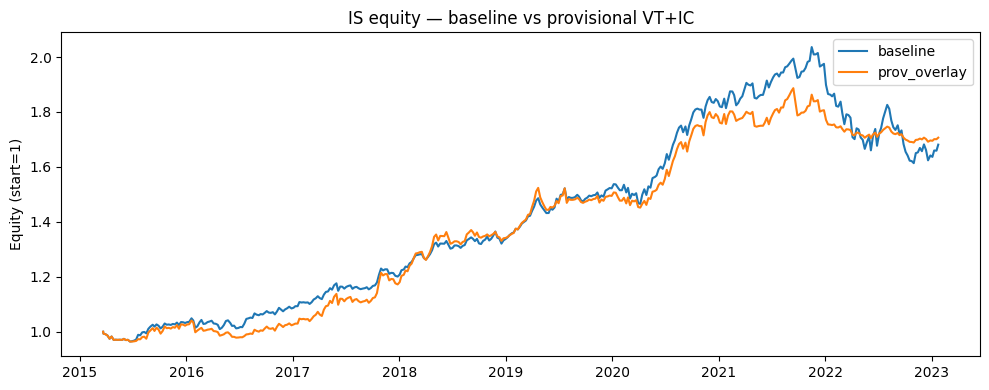

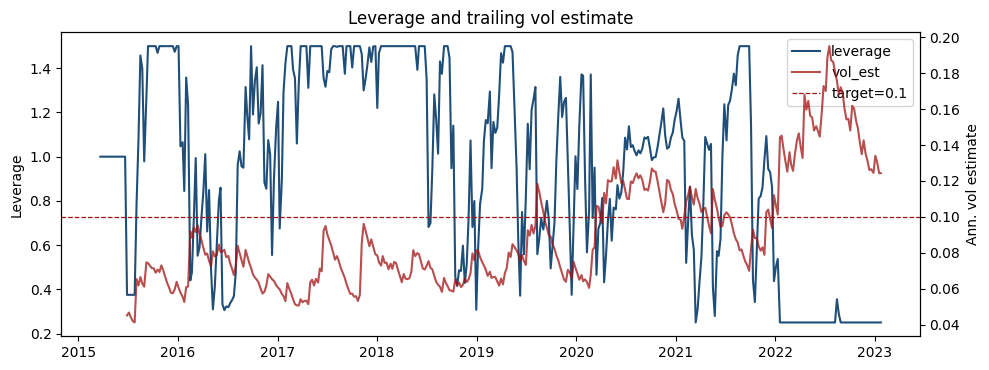

In [6]:
# Pick best combined by DD then 2022 then Sharpe (Sharpe floor vs baseline)
comb = ic_df.copy()
comb = comb[comb["sharpe"] >= base_sh - 0.05]
if comb.empty:
    comb = ic_df
best_comb = comb.sort_values(["max_drawdown", "ret_2022", "sharpe"], ascending=[False, False, False]).index[0]
VT_STAR_PROV, IC_STAR_PROV = best_comb.split("__", 1)
VT_CFG_PROV = parse_vol_target_star(VT_STAR_PROV)
IC_CFG_PROV = parse_ic_scale_star(IC_STAR_PROV)
print(f"Provisional VT_STAR={VT_STAR_PROV}")
print(f"Provisional IC_STAR={IC_STAR_PROV}")
res_prov = ic_results[best_comb]
fig = plot_equity_overlay(
    {"baseline": baseline.equity, "prov_overlay": res_prov.equity},
    title="IS equity — baseline vs provisional VT+IC",
)
plt.show()
fig = plot_leverage_and_vol(res_prov, target_ann_vol=VT_CFG_PROV.target_ann_vol)
plt.show()


## 6. Deadband vs no deadband (end-sample comparison)

### What a deadband is
Each Monday the overlay suggests a leverage number (e.g. 1.00× or 0.80× of the base book).
A **deadband** says: *if the new number is only a tiny change from last week’s leverage, keep last week’s number*.

Example: last week 1.00×, this week 0.97×, deadband 5% → stay at 1.00×.
A big move (1.00× → 0.80×) is still applied.

### Why that can matter under Mon→Mon
We do **not** always close every position on Monday open. Names that stay in the top/bottom-N keep a position; we only trade the **difference** vs last week (adds, drops, size changes). Changing leverage forces a small trim/add on every name that rolls — that is extra turnover and cost.
(Under Fri-flatten timing you fully rebuild each week, so deadband barely matters for trading costs.)

### What we test
Same selected VT + IC settings, once with `deadband=0` and once with a suitable deadband (`0.05` and `0.10`; pick the better “on” arm).


In [7]:
def with_deadband(cfg: VolTargetConfig, db: float) -> VolTargetConfig:
    return VolTargetConfig(
        enabled=cfg.enabled,
        target_ann_vol=cfg.target_ann_vol,
        estimator=cfg.estimator,
        window=cfg.window,
        halflife=cfg.halflife,
        forget=cfg.forget,
        quantile=cfg.quantile,
        min_periods=cfg.min_periods,
        warmup_leverage=cfg.warmup_leverage,
        min_leverage=cfg.min_leverage,
        max_leverage=cfg.max_leverage,
        periods_per_year=cfg.periods_per_year,
        vol_floor=cfg.vol_floor,
        deadband=float(db),
        alpha0=cfg.alpha0,
        beta0=cfg.beta0,
    )

db_rows = []
db_results = {}
for db, name in [(0.0, "no_deadband"), (0.05, "db_0.05"), (0.10, "db_0.10")]:
    cfg = with_deadband(VT_CFG_PROV, db)
    res = run_vt(cfg, IC_CFG_PROV)
    db_results[name] = res
    r = row_from_result(name, res)
    lev = res.leverage.dropna()
    r["mean_abs_dlev"] = float(lev.diff().abs().mean()) if len(lev) > 1 else np.nan
    r["vt_star"] = vol_target_star(cfg)
    db_rows.append(r)
    print(name, f"sharpe={r['sharpe']:.3f} turn={r['mean_turnover']:.4f} |dL|={r['mean_abs_dlev']:.4f}")

db_df = pd.DataFrame(db_rows).set_index("label")
display(db_df)

# Pick better of 0.05 / 0.10 by Sharpe, then lower turnover
on_arm = db_df.loc[["db_0.05", "db_0.10"]].sort_values(["sharpe", "mean_turnover"], ascending=[False, True]).index[0]
off = db_df.loc["no_deadband"]
on = db_df.loc[on_arm]
# Prefer deadband if turnover improves without material Sharpe loss
use_db = (on["mean_turnover"] < off["mean_turnover"] - 1e-6) and (on["sharpe"] >= off["sharpe"] - 0.03)
if not use_db:
    # also accept if Sharpe better
    use_db = on["sharpe"] > off["sharpe"] + 1e-6
VT_STAR = on["vt_star"] if use_db else db_df.loc["no_deadband", "vt_star"]
print(f"Deadband choice -> VT_STAR={VT_STAR}  (use_db={use_db}, on_arm={on_arm})")


no_deadband sharpe=1.000 turn=0.1985 |dL|=0.1173
db_0.05 sharpe=1.001 turn=0.1987 |dL|=0.1181
db_0.10 sharpe=0.988 turn=0.1994 |dL|=0.1203


,sharpe,max_drawdown,dd_length_weeks,vol,total_return,ret_2022,mean_leverage,mean_turnover,mean_cost_drag,mean_abs_dlev,vt_star
label,,,,,,,,,,,
no_deadband,1.000084,-0.104863,59.0,0.070288,0.706496,-0.060932,0.958041,0.198478,0.000306,0.117306,vt_bayes_0.9_10_q0.75
db_0.05,1.001401,-0.104923,59.0,0.070253,0.707306,-0.060938,0.957761,0.198678,0.000307,0.118088,vt_bayes_0.9_10_q0.75_db0.05
db_0.10,0.987931,-0.103291,59.0,0.070353,0.695851,-0.060938,0.956980,0.199406,0.000308,0.120321,vt_bayes_0.9_10_q0.75_db0.1


Deadband choice -> VT_STAR=vt_bayes_0.9_10_q0.75_db0.05  (use_db=True, on_arm=db_0.05)


## 7. Final selection → copy into notebook 08


In [8]:
IC_STAR = IC_STAR_PROV
VT_CFG = parse_vol_target_star(VT_STAR)
IC_CFG = parse_ic_scale_star(IC_STAR)
final = run_vt(VT_CFG, IC_CFG)
final_row = row_from_result("final", final)
print("FINAL overlay vs baseline")
display(pd.DataFrame([row_from_result("baseline", baseline), final_row]).set_index("label"))
print(f"Copy into 08_oos_tearsheet:")
print(f"  VT_STAR = {VT_STAR!r}")
print(f"  IC_STAR = {IC_STAR!r}")


FINAL overlay vs baseline


,sharpe,max_drawdown,dd_length_weeks,vol,total_return,ret_2022,mean_leverage,mean_turnover,mean_cost_drag
label,,,,,,,,,
baseline,0.881920,-0.207560,50.0,0.078220,0.681082,-0.168839,1.000000,0.172833,0.000266
final,1.001401,-0.104923,59.0,0.070253,0.707306,-0.060938,0.957761,0.198678,0.000307


Copy into 08_oos_tearsheet:
  VT_STAR = 'vt_bayes_0.9_10_q0.75_db0.05'
  IC_STAR = 'ic_k15_0.94_f0.25_c1.25'


## 8. Integrity checks


In [9]:
# Realized vol vs target
sm = summarize_periods(final.period_returns)
print(f"realized ann vol={sm['vol']:.3%}  target={VT_CFG.target_ann_vol:.3%}")
print(f"leverage autocorr(1)={final.leverage.dropna().autocorr(lag=1):.3f}")

# PIT: perturb future base returns must not change earlier leverage
r0 = final.period_returns_base.dropna().sort_index()
cfg = VT_CFG
from risk.analytics.s1_equities.vol_targeting import leverage_series
a = leverage_series(r0, cfg)["leverage"]
r1 = r0.copy()
r1.iloc[-8:] = r1.iloc[-8:] + 0.2
b = leverage_series(r1, cfg)["leverage"]
assert np.allclose(a.iloc[:-8], b.iloc[:-8], equal_nan=True)
print("PIT check OK: early leverage unchanged after future-return perturbation")


realized ann vol=7.025%  target=10.000%
leverage autocorr(1)=0.902
PIT check OK: early leverage unchanged after future-return perturbation
